In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#for logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix,classification_report


In [13]:
df=pd.read_csv('Data\Data\heart_disease_prediction.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [14]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [15]:
df['Sex'].unique()

<StringArray>
['M', 'F']
Length: 2, dtype: str

In [16]:
gender_id={
    'M':0,
    'F':1
}
df['GenderId']=df['Sex'].map(gender_id)

In [17]:
df['ChestPainType'].unique(
    
)

<StringArray>
['ATA', 'NAP', 'ASY', 'TA']
Length: 4, dtype: str

In [18]:
cpt_id={
    'ATA':0,
      'NAP':1,
       'ASY':2,

       'TA':3,
}
df['ChestPainType_id']=df['ChestPainType'].map(cpt_id)
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,GenderId,ChestPainType_id
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0,0,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1,1,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0,0,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1,1,2
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0,0,1


In [19]:
df['RestingECG'].unique()


<StringArray>
['Normal', 'ST', 'LVH']
Length: 3, dtype: str

In [20]:
re_id={
'Normal':0,
 'ST':1,
   'LVH':2
}
df['RestingECG']=df['RestingECG'].map(re_id)

In [21]:
df['ExerciseAngina'].unique()
ea_id = {'N': 0, 'Y': 1}
df['ExerciseAngina'] = df['ExerciseAngina'].map(ea_id)
df['ST_Slope'].unique()
ss_id = {'Up': 0, 'Flat': 1, 'Down': 2}
df['ST_Slope'] = df['ST_Slope'].map(ss_id)

In [22]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease', 'GenderId', 'ChestPainType_id'],
      dtype='str')

In [23]:
features=['Age', 'GenderId', 'ChestPainType_id', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope']




In [24]:

target = 'HeartDisease'
X = df[features]
Y = df[target]

In [25]:
X_train,X_test,Y_train,Y_test=train_test_split(
    #stratify only for target for equal distribution of binary data
    X,Y,test_size=0.2,random_state=42
)

In [26]:
#feature scaling
scaler=StandardScaler()
X_train_scale=scaler.fit_transform(X_train)#learn+implant
X_test_scale=scaler.transform(X_test)#implement

In [27]:
from sklearn.impute import SimpleImputer

#model training, fitting data and predict
model=LogisticRegression(
    class_weight='balanced',solver='liblinear',random_state= 42
)
imputer = SimpleImputer(strategy='mean')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

X_train_scale = scaler.fit_transform(X_train_imp)
X_test_scale = scaler.transform(X_test_imp)

model.fit(X_train_scale, Y_train)
Y_pred = model.predict(X_test_scale)
Y_pred=model.predict(X_test_scale)

In [28]:
cr= classification_report(Y_test,Y_pred)
cm= confusion_matrix(Y_test,Y_pred)
print (cr)

              precision    recall  f1-score   support

           0       0.76      0.84      0.80        77
           1       0.88      0.81      0.84       107

    accuracy                           0.83       184
   macro avg       0.82      0.83      0.82       184
weighted avg       0.83      0.83      0.83       184



<Axes: >

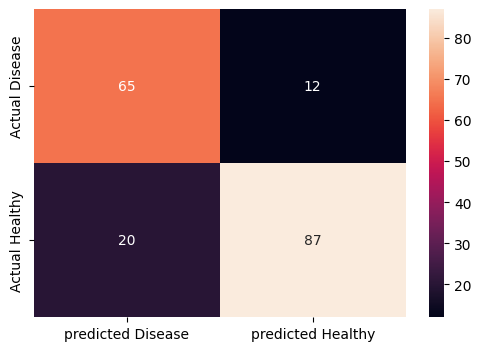

In [29]:
#heat map -> correlation
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,xticklabels=['predicted Disease','predicted Healthy'],
            yticklabels=['Actual Disease','Actual Healthy'])

In [30]:
#knn -> K -nearest neigbors
from sklearn.neighbors import KNeighborsClassifier




In [31]:
error_rate=[]
k_range=range(1,21)
for i in k_range:
    knn=KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_scale, Y_train)
    knn_pred=knn.predict(X_test_scale)
    error_rate.append(np.mean(Y_test!= knn_pred))


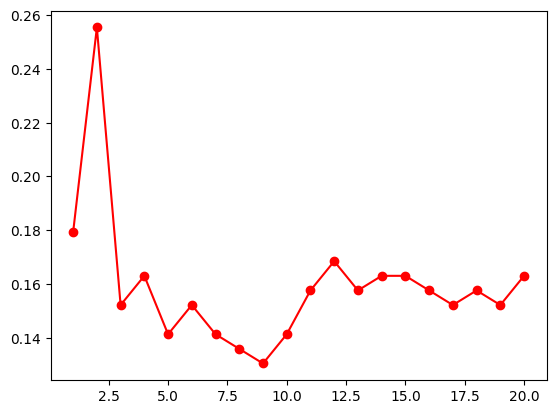

In [32]:
plt.plot(k_range,error_rate,c='red',marker='o')

In [35]:
K_model=KNeighborsClassifier(n_neighbors=7)
K_model.fit(X_train_scale,Y_train)
K_pred=K_model.predict(X_test_scale)



In [36]:
K_cr=classification_report(Y_test,K_pred)
K_cm=confusion_matrix(Y_test,K_pred)
print(K_cm)
print(K_cr)

[[66 11]
 [15 92]]
              precision    recall  f1-score   support

           0       0.81      0.86      0.84        77
           1       0.89      0.86      0.88       107

    accuracy                           0.86       184
   macro avg       0.85      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184

